In [1]:
import numpy as np
from dtaidistance import dtw
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd


In [ ]:
from tqdm import tqdm


In [5]:

# read data
cluster_df = pd.read_parquet('cluster_used_data.parquet')

# fetch feature columns
features = [col for col in cluster_df.columns if col not in ['symbol', 'report_date']]

# normalization
scaler = StandardScaler()
df_normalized = cluster_df.copy()
df_normalized[features] = scaler.fit_transform(cluster_df[features])

# fetch symbol
symbols = cluster_df['symbol'].unique()
n_symbols = len(symbols)

# calculate DTW distance matrix
distance_matrix = np.zeros((n_symbols, n_symbols))

for i, sym1 in tqdm(enumerate(symbols),desc='Symbol 1'):
    for j, sym2 in tqdm(enumerate(symbols),desc='Symbol 2'):
        if i >= j:
            continue
        
        # fetch time series for both symbols
        ts1 = df_normalized[df_normalized['symbol'] == sym1][features].values
        ts2 = df_normalized[df_normalized['symbol'] == sym2][features].values
        
        # calculate DTW distance for each feature
        dtw_distances = []
        for feat_idx in tqdm(range(len(features)),desc=f'Calculate distance between{sym1} and {sym2}'):
            try:
                d = dtw.distance(ts1[:, feat_idx], ts2[:, feat_idx])
                dtw_distances.append(d)
            except:
                dtw_distances.append(np.inf)
        
        # average distance, ignoring infinities
        valid_distances = [d for d in dtw_distances if d != np.inf]
        avg_distance = np.mean(valid_distances) if valid_distances else np.inf
        
        distance_matrix[i, j] = avg_distance
        distance_matrix[j, i] = avg_distance

print("Distance Matrix Shape:", distance_matrix.shape)
print("Distance Matrix:\n", distance_matrix)


Symbol 1: 0it [00:00, ?it/s]


Calculate distance between000063 and 000333: 100%|██████████| 7/7 [00:00<00:00, 695.23it/s]

Calculate distance between000063 and 000617: 100%|██████████| 7/7 [00:00<00:00, 987.92it/s]

Calculate distance between000063 and 000725: 100%|██████████| 7/7 [00:00<00:00, 872.96it/s]

Calculate distance between000063 and 000792: 100%|██████████| 7/7 [00:00<00:00, 1213.13it/s]

Calculate distance between000063 and 000938: 100%|██████████| 7/7 [00:00<00:00, 1109.86it/s]

Calculate distance between000063 and 002027: 100%|██████████| 7/7 [00:00<00:00, 1399.50it/s]

Calculate distance between000063 and 002230: 100%|██████████| 7/7 [00:00<00:00, 1403.51it/s]

Calculate distance between000063 and 002371: 100%|██████████| 7/7 [00:00<00:00, 1149.48it/s]

Calculate distance between000063 and 002475: 100%|██████████| 7/7 [00:00<00:00, 1396.57it/s]

Calculate distance between000063 and 002594: 100%|██████████| 7/7 [00:00<00:00, 1375.96it/s]

Calculate distance between000063 and 002714: 100%|██████████| 7

Distance Matrix Shape: (50, 50)
Distance Matrix:
 [[ 0.          1.42282746  9.26592358 ...  2.90636812  3.49794986
   2.99747161]
 [ 1.42282746  0.          9.90186392 ...  2.55536025  2.40618963
   3.82754997]
 [ 9.26592358  9.90186392  0.         ...  8.95216291 10.75779215
   8.50422896]
 ...
 [ 2.90636812  2.55536025  8.95216291 ...  0.          3.20341692
   2.37194874]
 [ 3.49794986  2.40618963 10.75779215 ...  3.20341692  0.
   5.02627828]
 [ 2.99747161  3.82754997  8.50422896 ...  2.37194874  5.02627828
   0.        ]]


c:\BASIC_LEARNING\DSA5101\Project2\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


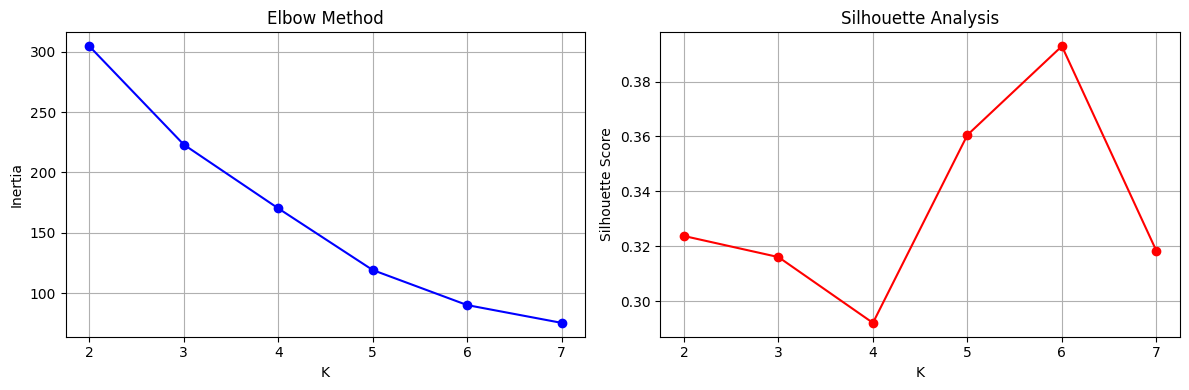

Optimal K: 6

Clustering Results:
    symbol  cluster
0   000063        1
1   000333        1
2   000617        2
3   000725        5
4   000792        3
5   000938        1
6   002027        0
7   002230        5
8   002371        0
9   002475        1
10  002594        1
11  002714        3
12  300015        0
13  300124        0
14  300408        0
15  300750        3
16  300760        0
17  600009        5
18  600019        1
19  600028        1
20  600030        0
21  600031        1
22  600036        4
23  600048        5
24  600111        1
25  600276        0
26  600309        1
27  600406        0
28  600415        0
29  600426        0
30  600436        0
31  600519        4
32  600585        0
33  600660        0
34  600887        1
35  600893        5
36  600900        0
37  600941        0
38  601012        1
39  601088        0
40  601318        3
41  601600        1
42  601668        1
43  601766        1
44  601816        5
45  601888        1
46  601899        1
47  60

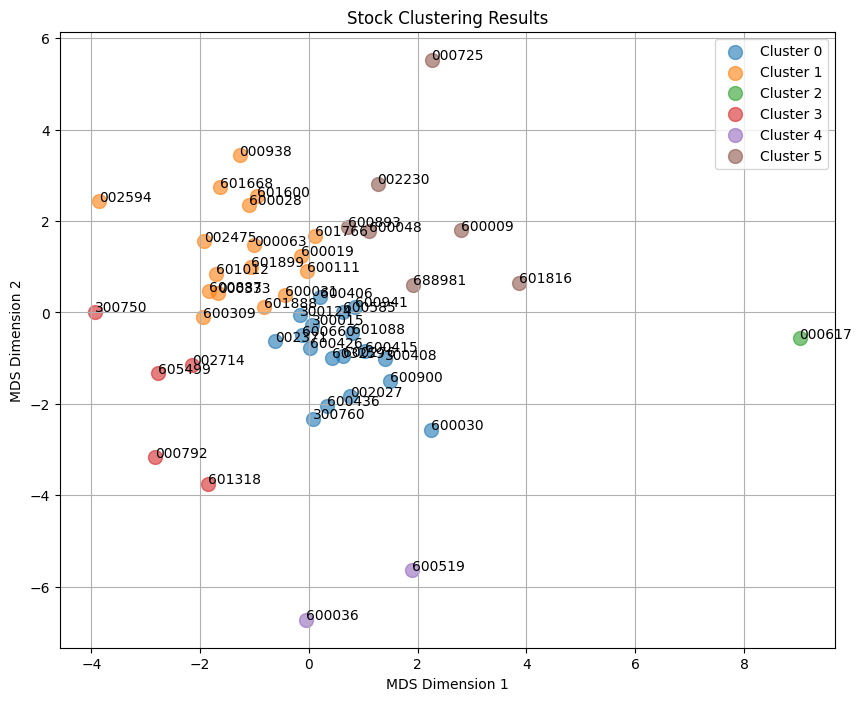

In [ ]:
#MDS demension reduction
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
embeddings = mds.fit_transform(distance_matrix)

# K-means
inertias = []
silhouette_scores = []
k_range = range(2, min(8, n_symbols))

from sklearn.metrics import silhouette_score

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(embeddings, labels))

# plot interias and silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('K')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid()

ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('K')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid()
plt.tight_layout()
plt.show()

# choose optimal k according to silhouette scores
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal K: {optimal_k}")

# final clustering 
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(embeddings)

# output results
result_df = pd.DataFrame({
    'symbol': symbols,
    'cluster': cluster_labels
})
print("\nClustering Results:")
print(result_df)

# visualize clustering results
plt.figure(figsize=(10, 8))
for cluster_id in range(optimal_k):
    mask = cluster_labels == cluster_id
    plt.scatter(embeddings[mask, 0], embeddings[mask, 1], 
               label=f'Cluster {cluster_id}', s=100, alpha=0.6)
    for idx, sym in enumerate(symbols[mask]):
        plt.annotate(sym, (embeddings[mask][idx, 0], embeddings[mask][idx, 1]))

plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.title('Stock Clustering Results')
plt.legend()
plt.grid()
plt.show()
